## Imports

In [2]:
import qiskit
qiskit.__version__

'2.3.0'

In [3]:
from qiskit_aer import Aer
Aer.backends()
import qiskit_ibm_runtime.fake_provider as fp
[x for x in dir(fp) if x.startswith("Fake")]

import qiskit_aer
from qiskit import QuantumCircuit, quantum_info, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter
from qiskit.visualization import plot_distribution, plot_histogram, array_to_latex

from qiskit import transpile
import numpy as np
import matplotlib.pyplot as plt

from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeGuadalupeV2
from qiskit_ibm_runtime import QiskitRuntimeService

### OR, AND, XOR, and NOT gate definitions.

In [15]:
def OR(qc, a, b, c):
    # Computes c = a OR b; a and b are restored after the gate.
    # Uses De Morgan: a OR b = NOT(NOT a AND NOT b)
    qc.x(a)
    qc.x(b)
    qc.ccx(a, b, c)
    qc.x(a)
    qc.x(b)
    qc.x(c)
    return qc

def AND(qc, a, b, c):
    qc.mcx([a, b], c)
    return qc

def NOT(qc, a):
    qc.x(a)
    return qc

def XOR(qc, a, b, c):
    qc.cx(a, c)
    qc.cx(b, c)
    return qc

# Party Problem

### Classical evaluation of $f = ((A \land B) \lor (C \land D)) \land \lnot(A \land D)$.}

In [5]:
def classical(a, b, c, d):
    ab = a and b
    cd = c and d
    ad = a and d
    ab_or_cd = ab or cd
    f = ab_or_cd and not ad
    return int(f)

solutions = []
for a in [0, 1]:
    for b in [0, 1]:
        for c in [0, 1]:
            for d in [0, 1]:
                if classical(a, b, c, d) == 1:
                    solutions.append((a, b, c, d))
print(solutions)
# Output: [(0,0,1,1), (0,1,1,1), (1,1,0,0), (1,1,1,0)]

[(0, 0, 1, 1), (0, 1, 1, 1), (1, 1, 0, 0), (1, 1, 1, 0)]


### Party oracle implementing $f$ with compute--mark--uncompute structure.

In [19]:
# Qubit registers (defined globally, reused by Oparty and Grover)
vq = QuantumRegister(4, name='v')   # variable qubits: A, B, C, D
cq = QuantumRegister(4, name='c')   # ancilla qubits
checkqubit = QuantumRegister(1, name='out')  # output qubit

def Oparty(qc):
    # --- Compute ---
    qc.ccx(vq[0], vq[1], cq[0])        # cq[0] = A AND B
    qc.ccx(vq[2], vq[3], cq[1])        # cq[1] = C AND D
    OR(qc, cq[0], cq[1], cq[2])        # cq[2] = (A AND B) OR (C AND D)
    qc.ccx(vq[0], vq[3], cq[3])        # cq[3] = A AND D
    qc.x(cq[3])                         # cq[3] = NOT (A AND D)
    # --- Mark (phase kickback) ---
    qc.mcx([cq[2], cq[3]], checkqubit)
    # --- Uncompute ---
    qc.x(cq[3])
    qc.ccx(vq[0], vq[3], cq[3])
    OR(qc, cq[0], cq[1], cq[2])
    qc.ccx(vq[2], vq[3], cq[1])
    qc.ccx(vq[0], vq[1], cq[0])
    return qc

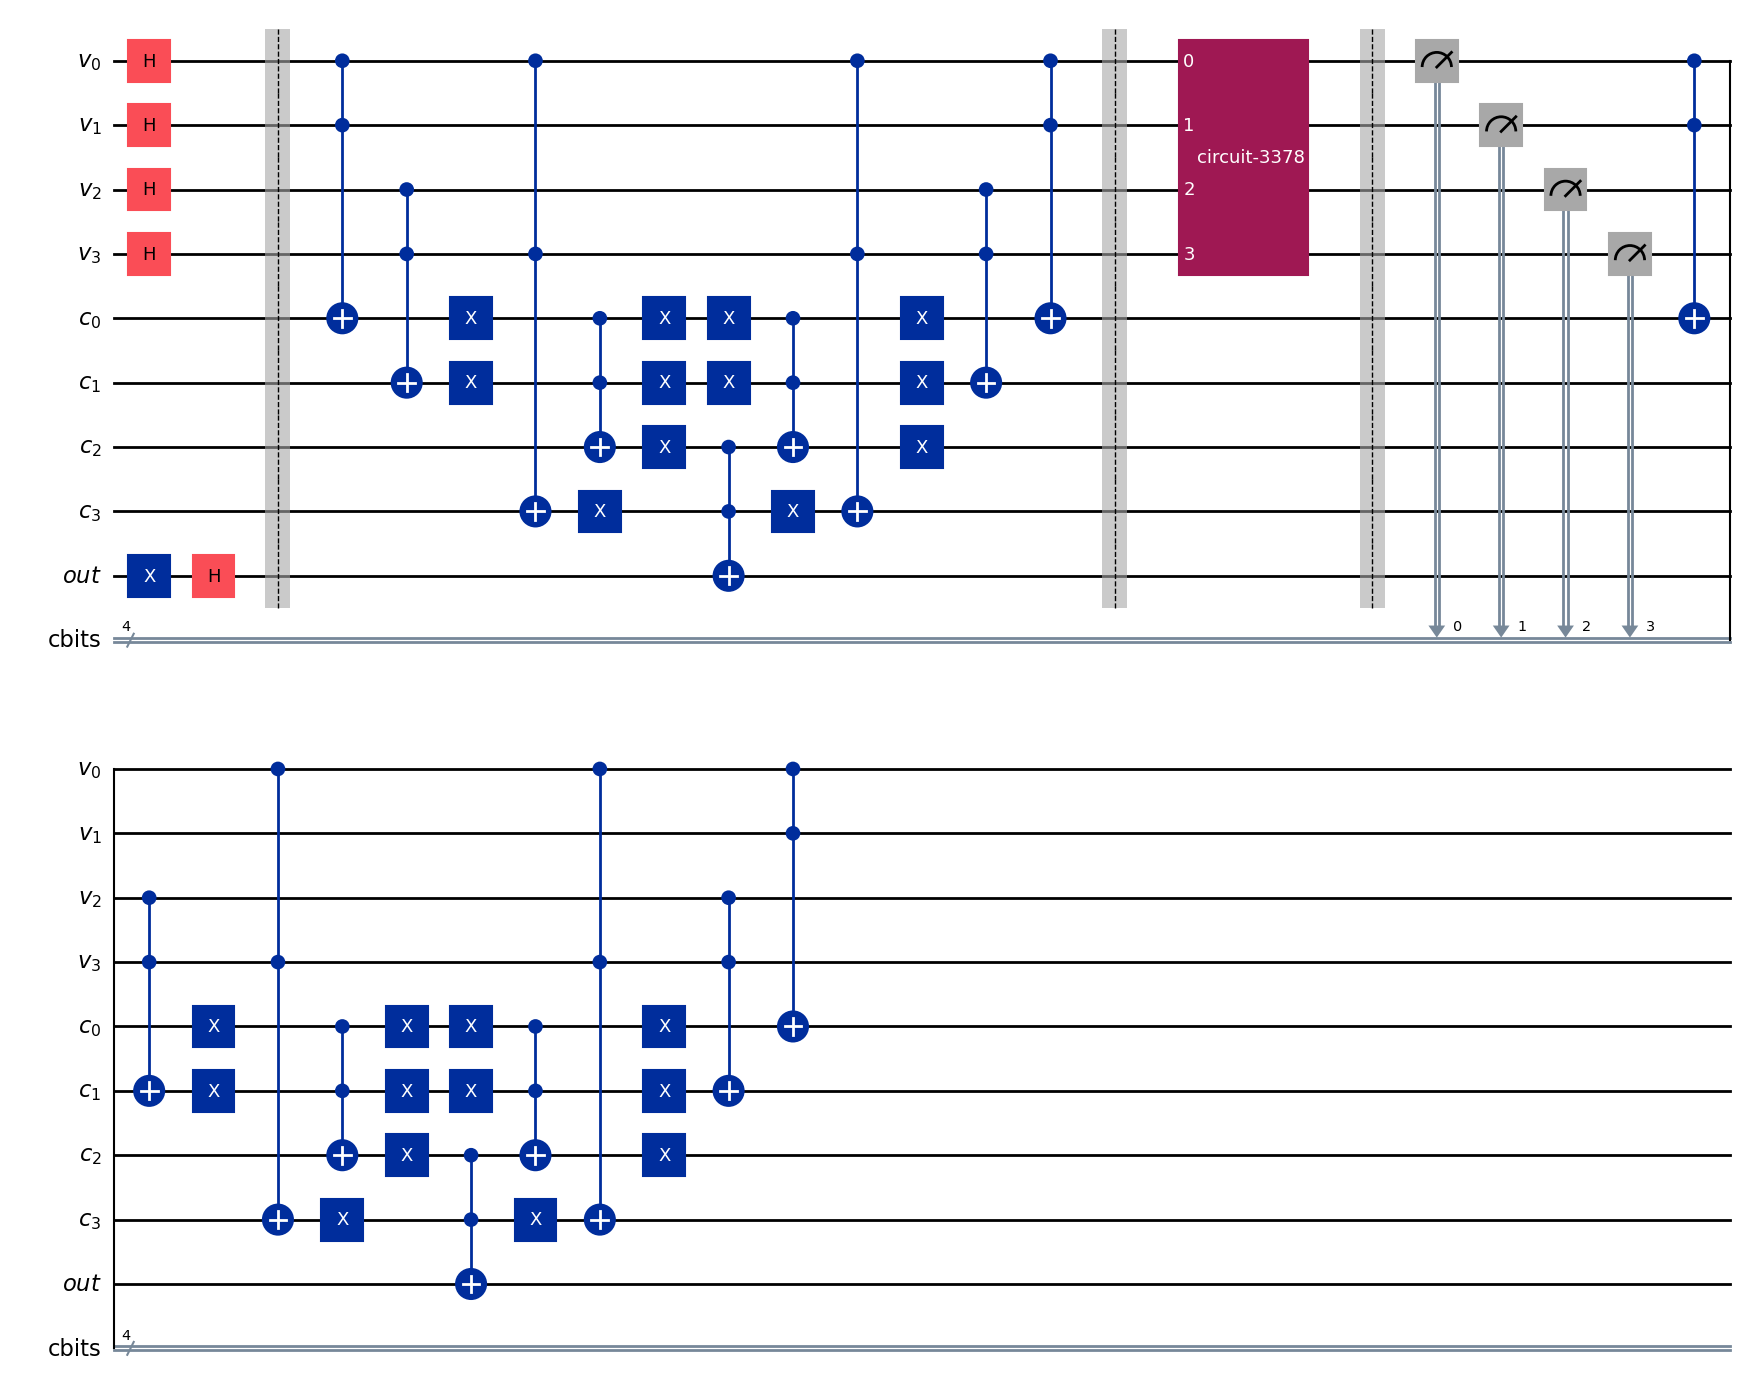

In [20]:
Oparty(qc)
qc.draw('mpl')

### Grover diffuser implementing $R = H^{\otimes n} X^{\otimes n}\, MCZ\, X^{\otimes n} H^{\otimes n}$.

In [7]:
def multiZ(qc):
    # Multi-controlled-Z via H + MCX + H on the last qubit
    n = qc.num_qubits
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    return qc

def diffuser(n=4):
    qc = QuantumCircuit(n)
    for i in range(n):
        qc.h(i)         # |psi> -> |00..0>
    for i in range(n):
        qc.x(i)         # |00..0> -> |11..1>
    multiZ(qc)          # flip phase of |11..1>
    for i in range(n):
        qc.x(i)         # |11..1> -> |00..0>
    for i in range(n):
        qc.h(i)         # |00..0> -> |psi>
    return qc

### Full Grover circuit for the party problem with \texttt{ite} iterations.

In [17]:
def Grover(ite=1):
    vq = QuantumRegister(4, name='v')
    cq = QuantumRegister(4, name='c')
    checkqubit = QuantumRegister(1, name='out')
    cbits = ClassicalRegister(4, name='cbits')
    qc = QuantumCircuit(vq, cq, checkqubit, cbits)

    # Initialisation: uniform superposition + |-> on output qubit
    qc.h(vq)
    qc.x(checkqubit)
    qc.h(checkqubit)
    qc.barrier()

    for _ in range(ite):
        Oparty(qc)            # oracle
        qc.barrier()
        qc.append(diffuser(4), vq)  # diffuser
        qc.barrier()

    qc.measure(vq, cbits)
    return qc

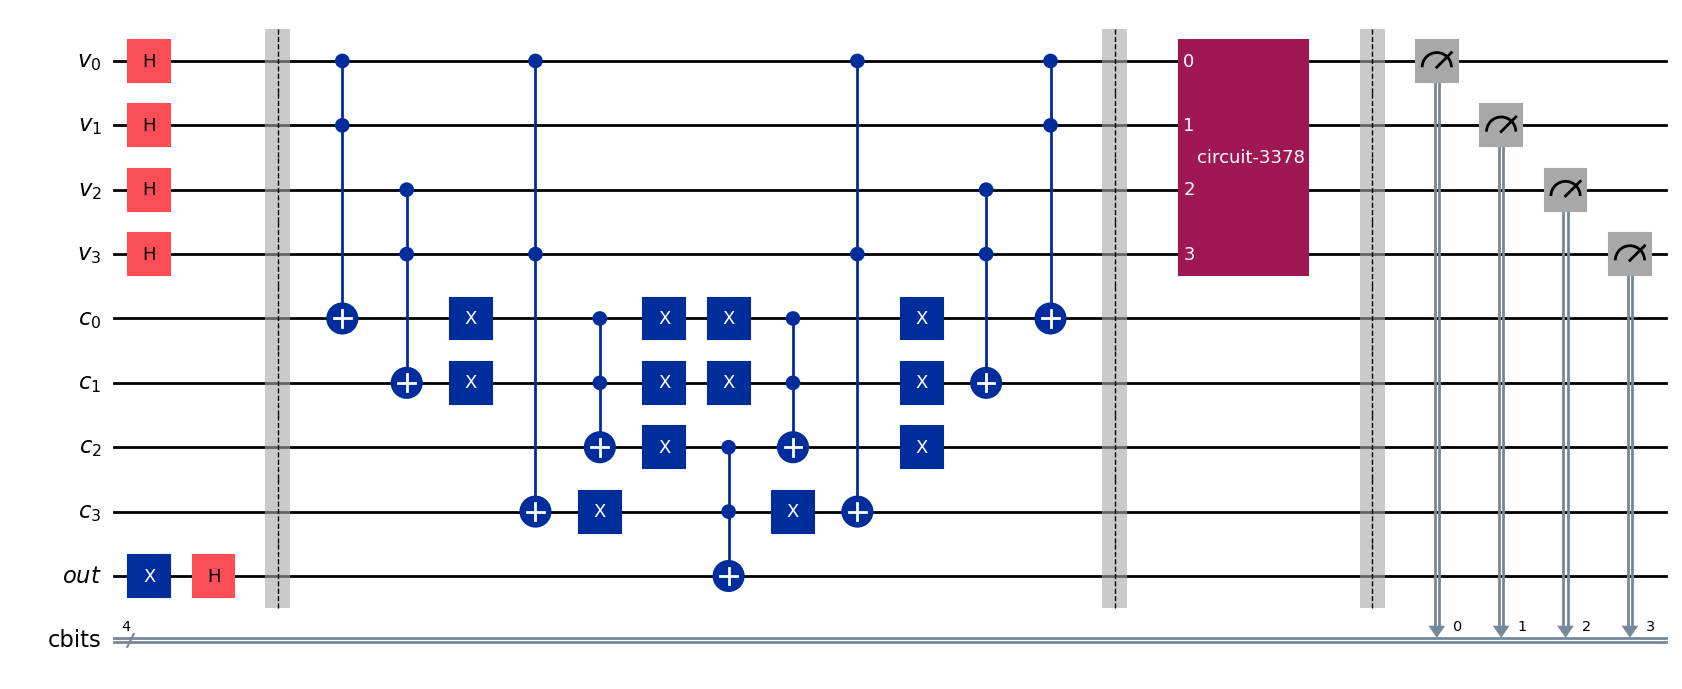

In [18]:
qc = Grover(ite=1)
qc.draw('mpl')

### Simulation runner using FakeGuadalupeV2 as noise model.

In [9]:
def run_fake(qc, device_backend, noise_model=None, Nshots=1024):
    qc_transpiled = transpile(qc, device_backend)
    sim_faked = AerSimulator.from_backend(device_backend)
    if noise_model == True:
        result = sim_faked.run(qc_transpiled, shots=Nshots).result()
    else:
        result = sim_faked.run(qc_transpiled, shots=Nshots,
                               noise_model=None).result()
    counts = result.get_counts()
    return qc_transpiled, counts

### Ideal simulation for $k=1$ and $k=2$; export to party\_iterations.png.

In [ ]:
qc1, counts1 = run_fake(Grover(ite=1), FakeGuadalupeV2(), False, Nshots=4096)
qc2, counts2 = run_fake(Grover(ite=2), FakeGuadalupeV2(), False, Nshots=4096)

fig = plot_distribution(
    [counts1, counts2],
    legend=["k=1", "k=2"],
    color=["#80ED99", "#9D4EDD"],
    figsize=(12, 5)
)
fig.savefig("party_iterations.png", bbox_inches="tight", dpi=150)

### Ideal vs. noisy simulation for $k=1$; export to party_noise.png.

In [ ]:
qc_ideal, counts_ideal = run_fake(Grover(ite=1), FakeGuadalupeV2(), False,
                                  Nshots=4096)
qc_noisy, counts_noisy = run_fake(Grover(ite=1), FakeGuadalupeV2(), True,
                                  Nshots=4096)

fig = plot_distribution(
    [counts_ideal, counts_noisy],
    legend=["Ideal", "Noisy"],
    color=["#80ED99", "#2B2D42"],
    figsize=(12, 5)
)
fig.savefig("party_noise.png", bbox_inches="tight", dpi=150)

# Sudoku Problem

### Constraint checker: evaluates all four Sudoku clauses and stores the joint result in out.

In [10]:
# Qubit registers (defined globally, reused by check, Osudoku, and Grover)
vqubits  = QuantumRegister(4, name='v')    # Sudoku cell values: A, B, C, D
cqubits  = QuantumRegister(4, name='c')    # ancilla: one per clause
checkqubit = QuantumRegister(1, name='out') # output qubit

def check(qc, clause_list=[[0, 1], [0, 2], [1, 3], [2, 3]]):
    # clause_list encodes the pairs (v_i, v_j) that must differ:
    #   [0,1] -> v0 != v1  (top row)
    #   [0,2] -> v0 != v2  (left column)
    #   [1,3] -> v1 != v3  (right column)
    #   [2,3] -> v2 != v3  (bottom row)
    i = 0
    for vq in clause_list:
        XOR(qc, vq[0], vq[1], cqubits[i])   # c[i] = 1 iff v_i != v_j
        i += 1
    qc.mcx(cqubits, checkqubit)              # out = 1 iff all clauses hold
    return qc

### Sudoku oracle: compute clauses, mark valid states via phase kickback, uncompute ancilla.

In [11]:
def Osudoku(qc):
    clause_list = [[0, 1], [0, 2], [1, 3], [2, 3]]
    # --- Compute + mark ---
    check(qc)
    # --- Uncompute (restore ancilla to |0>) ---
    i = 0
    for vq in clause_list:
        XOR(qc, vq[0], vq[1], cqubits[i])
        i += 1
    return qc

### Full Grover circuit for the Sudoku problem with {ite} iterations.

In [12]:
def Grover(ite=1):
    vqubits    = QuantumRegister(4, name='v')
    cqubits    = QuantumRegister(4, name='c')
    checkqubit = QuantumRegister(1, name='out')
    cbits      = ClassicalRegister(4, name='cbits')
    qc = QuantumCircuit(vqubits, cqubits, checkqubit, cbits)

    # Initialisation: uniform superposition + |-> on output qubit
    qc.h(vqubits)
    qc.x(checkqubit)
    qc.h(checkqubit)
    qc.barrier()

    for _ in range(ite):
        Osudoku(qc)                         # oracle
        qc.barrier()
        qc.append(diffuser(4), [0, 1, 2, 3])  # diffuser
        qc.barrier()

    qc.measure(vqubits, cbits)
    return qc

### Ideal simulation for $k = 1$, $2$, $3$; export to sudoku_iterations.png.

In [16]:
qc1, c1 = run_fake(Grover(ite=1), FakeGuadalupeV2(), False, Nshots=4096)
qc2, c2 = run_fake(Grover(ite=2), FakeGuadalupeV2(), False, Nshots=4096)
qc3, c3 = run_fake(Grover(ite=3), FakeGuadalupeV2(), False, Nshots=4096)

fig = plot_distribution(
    [c1, c2, c3],
    legend=["k=1", "k=2", "k=3"],
    color=["#2B2D42", "#80ED99", "#9D4EDD"],
    figsize=(12, 4)
)
fig.savefig('sudoku_iterations.png', bbox_inches='tight', dpi=150)

### Ideal vs. noisy simulation for $k=2$; export to sudoku_noise.pNG.

In [ ]:
qcI, cI = run_fake(Grover(ite=2), FakeGuadalupeV2(), False, Nshots=4096)
qcN, cN = run_fake(Grover(ite=2), FakeGuadalupeV2(), True, Nshots=4096)

fig = plot_distribution(
    [cI, cN],
    legend=["Ideal", "Noisy"],
    color=["#80ED99", "#2B2D42"],
    figsize=(12, 4)
)
fig.savefig('sudoku_noise.png', bbox_inches='tight', dpi=150)